# HANNA: Quality Analysis with Text-Level Human-Relative Distance Scores

**Goal:** Test whether the distance of a model-generated story from the prompt-specific human reference set is associated with human-rated story quality.

For each eligible prompt, five human continuations form the human reference set. Human-relative distance scores are computed per text and per diversity dimension and linked to HANNA's quality ratings.

In [1]:
import json
import pathlib
import pickle
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from datasets import load_dataset
from scipy import stats
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Output locations (relative to quality/)
RESULTS_DIR = pathlib.Path('results')
FIGURE_DIR = pathlib.Path('../figures/quality_analysis')
for _dir in (RESULTS_DIR, FIGURE_DIR):
    _dir.mkdir(parents=True, exist_ok=True)


def save_figure(filename, **kwargs):
    """Save the current figure to FIGURE_DIR and return the path."""
    kwargs.setdefault('dpi', 300)
    kwargs.setdefault('bbox_inches', 'tight')
    path = FIGURE_DIR / filename
    plt.savefig(path, **kwargs)
    print(f'Saved: {path}')
    return path

## Load & Prepare Data

Ratings are averaged over annotators per story. **Overall** is the unweighted mean of the six HANNA criteria (Relevance, Coherence, Empathy, Surprise, Engagement, Complexity).

In [3]:
HANNA_PATH = '../data/hanna_stories_annotations.csv'
HUMAN_CRITERIA = ['Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity']

ann = pd.read_csv(HANNA_PATH)
print(f'Raw annotations: {len(ann)} rows')
print(f'Columns: {list(ann.columns)}')

# Aggregate to story level (mean over annotators)
stories = (
    ann
    .groupby(['Story ID', 'Model', 'Prompt', 'Story'])[HUMAN_CRITERIA]
    .mean()
    .reset_index()
)
stories['Overall'] = stories[HUMAN_CRITERIA].mean(axis=1)
stories['word_count'] = stories['Story'].apply(lambda t: len(t.split()))

print(f'\nStories (aggregated): {len(stories)}')
print(f'Generators ({stories["Model"].nunique()}): {sorted(stories["Model"].unique())}')
stories.head(3)

Raw annotations: 3168 rows
Columns: ['Story ID', 'Prompt', 'Human', 'Story', 'Model', 'Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Worker ID', 'Assignment ID', 'Work time in seconds', 'Name']

Stories (aggregated): 1056
Generators (11): ['BertGeneration', 'CTRL', 'Fusion', 'GPT', 'GPT-2', 'GPT-2 (tag)', 'HINT', 'Human', 'RoBERTa', 'TD-VAE', 'XLNet']


,Story ID,Model,Prompt,Story,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Overall,word_count
0,0,Human,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...",3.666667,3.666667,2.333333,2.333333,3.333333,2.666667,3.000000,210
1,1,Human,A new law is enacted that erases soldiers memo...,"“Dad, you 're on TV again !” I heard Eric 's v...",5.000000,4.666667,4.000000,3.666667,3.666667,4.000000,4.166667,266
2,2,Human,A scientific study proves that all humans have...,"When Tyler entered the ward, his daughter Vale...",4.666667,4.666667,4.000000,4.333333,4.000000,4.333333,4.333333,768


## Merge Additional Human References from WritingPrompts

HANNA contains only one human story per prompt, so further human continuations of the same prompt are retrieved from the original WritingPrompts dataset. HANNA's story stays reference #1; all other matches are deduplicated against it and against each other.

In [4]:
def detokenize(text):
    """Undo WritingPrompts' pre-tokenization (same as data_generation/writingprompts_generation.ipynb)."""

    text = text.replace('<newline>', '\n')
    text = re.sub(r'\s+([,.!?;:\'])', r'\1', text)
    text = re.sub(r'\s*\n\s*', '\n', text)
    text = re.sub(r'[ \t]{2,}', ' ', text)

    return text.strip()


def normalize_for_match(text):
    """Lowercased, punctuation-stripped matching key -> robust to bracket tags anywhere in the
    string, curly vs. straight quotes, and leftover contraction spacing (`does n't`)."""

    text = text.lower()
    text = re.sub(r'\[[^\]]*\]', ' ', text)
    text = text.replace('“', '"').replace('”', '"').replace('’', "'").replace('‘', "'")
    text = re.sub(r'[^a-z0-9]+', ' ', text)

    return re.sub(r'\s+', ' ', text).strip()

def same_underlying_story(a, b, n_words=100):
    """True if both stories share their first `n_words` normalized words (at least 50)."""
    a_words = normalize_for_match(a).split()
    b_words = normalize_for_match(b).split()

    k = min(n_words, len(a_words), len(b_words))

    if k < 50:
        return False

    return a_words[:k] == b_words[:k]


# Pool every human continuation for each HANNA prompt across all three source splits
wp_ds = load_dataset('euclaise/writingprompts')
source_stories_by_key = {}
for split in ('test', 'train', 'validation'):
    for r in wp_ds[split]:
        key = normalize_for_match(detokenize(r['prompt']))
        source_stories_by_key.setdefault(key, []).append(detokenize(r['story']))

print(f'Source dataset: {sum(len(v) for v in source_stories_by_key.values()):,} stories '
      f'across {len(source_stories_by_key):,} unique prompts (train+test+validation)')

Source dataset: 303,358 stories across 107,801 unique prompts (train+test+validation)


In [5]:
hanna_human = stories.loc[stories['Model'] == 'Human', ['Story ID', 'Prompt', 'Story']].reset_index(drop=True)

merged_records = []
for _, row in hanna_human.iterrows():
    hanna_key = normalize_for_match(row['Prompt'])

    candidates = source_stories_by_key.get(hanna_key, [])
    extra_refs = []

    for story in candidates:

        # Skip exact duplicates and the same underlying story (shared opening words)
        if any(
            normalize_for_match(story) == normalize_for_match(prev)
            or same_underlying_story(story, prev)
            for prev in [row['Story']] + extra_refs
        ):
            continue

        extra_refs.append(story)


    # HANNA's own story stays reference #1
    human_refs = [row['Story']] + extra_refs
    merged_records.append({
        'story_id': int(row['Story ID']),
        'prompt': row['Prompt'],
        'human_refs': human_refs,
        'n_refs': len(human_refs),
        'n_extra_refs': len(extra_refs),
    })

# Save the merged references
df_refs = pd.DataFrame(merged_records)
OUT_PATH = RESULTS_DIR / 'hanna_human_refs_merged.jsonl'
with open(OUT_PATH, 'w') as f:
    for rec in merged_records:
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')


print(f'Saved {len(merged_records)} prompts -> {OUT_PATH}')
print(f"refs per prompt: min={df_refs['n_refs'].min()}, median={df_refs['n_refs'].median():.1f}, "
      f"mean={df_refs['n_refs'].mean():.2f}, max={df_refs['n_refs'].max()}")
print(f"prompts with no extra refs found beyond the original HANNA story: "
      f"{(df_refs['n_extra_refs'] == 0).sum()}/{len(df_refs)}")
df_refs[['story_id', 'n_refs', 'n_extra_refs']].sort_values('n_refs').head()

Saved 96 prompts -> results/hanna_human_refs_merged.jsonl
refs per prompt: min=1, median=7.5, mean=13.25, max=91
prompts with no extra refs found beyond the original HANNA story: 3/96


,story_id,n_refs,n_extra_refs
17,17,1,0
92,92,1,0
48,48,1,0
30,30,2,1
16,16,2,1


In [6]:
# Verify that HANNA's own story (human_refs[0]) never recurs among a prompt's extra refs
dup_own_text = []
for rec in merged_records:
    hanna_story = rec['human_refs'][0]
    hanna_key = normalize_for_match(hanna_story)

    for extra in rec['human_refs'][1:]:
        if normalize_for_match(extra) == hanna_key or same_underlying_story(hanna_story, extra):
            dup_own_text.append(rec['story_id'])
            break

assert not dup_own_text, f"HANNA's own reference story recurs among extra_refs for: {dup_own_text}"
print(f"Verified: HANNA's own reference story does not recur among extra_refs for any of the "
      f"{len(merged_records)} prompts.")

Verified: HANNA's own reference story does not recur among extra_refs for any of the 96 prompts.


In [7]:
validation = []

# Check that every HANNA human story is found in WritingPrompts (exact or same underlying story)
for _, row in hanna_human.iterrows():
    prompt_key = normalize_for_match(row["Prompt"])
    candidates = source_stories_by_key.get(prompt_key, [])

    exact_match = any(
        normalize_for_match(candidate) == normalize_for_match(row["Story"])
        for candidate in candidates
    )

    underlying_match = any(
        same_underlying_story(row["Story"], candidate)
        for candidate in candidates
    )

    validation.append({
        "story_id": row["Story ID"],
        "n_source_stories": len(candidates),
        "hanna_human_found": exact_match or underlying_match,
        "match_type": (
            "exact" if exact_match
            else ("same_underlying_story" if underlying_match else "not_found")
        ),
    })

validation = pd.DataFrame(validation)

print(validation["hanna_human_found"].value_counts())
print("\nMatch types:")
print(validation["match_type"].value_counts())
display(validation[~validation["hanna_human_found"]])

hanna_human_found
True    96
Name: count, dtype: int64

Match types:
match_type
exact                    73
same_underlying_story    23
Name: count, dtype: int64


,story_id,n_source_stories,hanna_human_found,match_type


## Construct Fixed Human Reference Sets

Keep prompts with at least five human continuations. Each reference set contains the HANNA story plus four reproducibly sampled WritingPrompts continuations.

In [8]:
SEED = 42
N_HUMANS = 5
REF_SIZE = 3

df_refs["prompt_key"] = df_refs["prompt"].apply(normalize_for_match)

eligible_refs = df_refs.loc[df_refs["n_refs"] >= N_HUMANS].copy()

# Sanity check: every normalized prompt key should be unique here
assert eligible_refs["prompt_key"].is_unique


def sample_human_refs(row):
    refs = row["human_refs"]

    # refs[0] is always the original HANNA human story
    rng = np.random.default_rng(SEED + int(row["story_id"]))

    chosen = rng.choice(
        np.arange(1, len(refs)),
        size=N_HUMANS - 1,
        replace=False
    )

    return [refs[0]] + [refs[i] for i in chosen]


# HANNA story + 4 sampled continuations per prompt
eligible_refs["human_refs_5"] = eligible_refs.apply(
    sample_human_refs,
    axis=1
)

print(f"Eligible prompts: {len(eligible_refs)}")
print(eligible_refs["human_refs_5"].apply(len).value_counts())

Eligible prompts: 68
human_refs_5
5    68
Name: count, dtype: int64


In [ ]:

# Filter the model stories to only those that have at least 5 human references available
stories["prompt_key"] = stories["Prompt"].apply(normalize_for_match)

eligible_keys = set(eligible_refs["prompt_key"])

model_targets = stories.loc[
    (stories["Model"] != "Human") &
    (stories["prompt_key"].isin(eligible_keys))
].copy()

print("Model stories:", len(model_targets))
print("Prompts:", model_targets["prompt_key"].nunique())
print("Stories per prompt:")
print(model_targets.groupby("prompt_key").size().value_counts())

Model stories: 680
Prompts: 68
Stories per prompt:
10    68
Name: count, dtype: int64


In [10]:
# Export the primary quality-analysis sample (Story IDs only)
QUALITY_SAMPLE_IDS_PATH = RESULTS_DIR / 'hanna_quality_sample_story_ids.csv'
model_targets[['Story ID']].to_csv(QUALITY_SAMPLE_IDS_PATH, index=False)
print(f'{len(model_targets)} primary-sample Story IDs -> {QUALITY_SAMPLE_IDS_PATH}')

680 primary-sample Story IDs -> results/hanna_quality_sample_story_ids.csv


## Text-Level Human-Relative Distance Score `r(t)`

For every reference-control split (3 of the 5 human texts form `H_ref`), each text's distance to `H_ref` is computed and averaged over all splits in which the text is not itself part of `H_ref`:

- `r_mean(t)`: mean distance to `H_ref`, divided by the median of the same value over the prompt's human texts
- `r_min(t)`: the same with the distance to the nearest reference

`r(t) = 1` means a text is as far from the human references as a typical held-out human text. Scores are computed separately per diversity dimension.

In [ ]:
# Add the repo root to sys.path so we can import metrics_lib
def find_repo_root(start=None):
    start = pathlib.Path(start or pathlib.Path.cwd())

    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/')")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metrics.metrics_lib.pairwise import (
    distance_matrix, style_distance_matrices, reference_control_splits_rowwise, slices_from_lengths,
)


DIST_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr']
PAIRING_METRICS = DIST_METRICS + ['D_style']


def build_segments(refs_df, refs_col, targets):
    """Map each prompt to [('human', refs), (model, [story]), ...] and each text to its HANNA Story ID.

    Only prompts with at least one model story in `targets` are included.
    """
    segments, ids = {}, {}
    for _, row in refs_df.iterrows():
        pid = row['prompt_key']
        model_rows = targets.loc[targets['prompt_key'] == pid]
        if model_rows.empty:
            continue

        # First segment: the human references (HANNA's own story first), then one segment per model story
        segs = [('human', row[refs_col])]
        ids[(pid, 'human', 0)] = row['story_id']
        for _, mrow in model_rows.iterrows():
            segs.append((mrow['Model'], [mrow['Story']]))
            ids[(pid, mrow['Model'], 0)] = mrow['Story ID']
        segments[pid] = segs

    return segments, ids


segments_by_prompt, id_map = build_segments(eligible_refs, 'human_refs_5', model_targets)

print(f'{len(segments_by_prompt)} prompts with human refs + model stories')
print('model stories per prompt:',
      pd.Series([len(v) - 1 for v in segments_by_prompt.values()]).value_counts().sort_index().to_dict())

68 prompts with human refs + model stories
model stories per prompt: {10: 68}


In [ ]:
def load_or_compute_matrices(segments, cache_path):
    """Pairwise distance matrices per (metric, prompt), cached in `cache_path` after every metric."""
    if cache_path.exists():
        with open(cache_path, 'rb') as fh:
            matrices = pickle.load(fh)
    else:
        matrices = {}

    for metric in DIST_METRICS:

        # Check which prompts are already cached for this metric
        pending = [pid for pid in segments if (metric, pid) not in matrices]
        if not pending:
            print(f'{metric}: all {len(segments)} cached')
            continue

        # Compute the distance matrices for the pending prompts
        for pid in tqdm(pending, desc=metric):
            texts = [t for _, seg in segments[pid] for t in seg]
            try:
                matrices[(metric, pid)] = distance_matrix(metric, texts)
            except Exception as exc:
                warnings.warn(f'{metric}/{pid} failed: {exc!r}')
                matrices[(metric, pid)] = None

        # Cache the matrices after each metric
        with open(cache_path, 'wb') as fh:                       # checkpoint after every metric
            pickle.dump(matrices, fh)
        ok = sum(1 for pid in segments if matrices.get((metric, pid)) is not None)
        print(f'{metric}: {ok}/{len(segments)} matrices computed')

    # D_style: per-pair components winsorized + min-max normalized across every
    # (prompt, humans+models) block at once -> compute in one shot, not per prompt.
    if all(('D_style', pid) in matrices for pid in segments):
        print('D_style: all cached')
    else:
        seg_texts = {pid: [t for _, seg in segs for t in seg] for pid, segs in segments.items()}
        for pid, M in style_distance_matrices(seg_texts).items():
            matrices[('D_style', pid)] = M
        with open(cache_path, 'wb') as fh:
            pickle.dump(matrices, fh)
        ok = sum(1 for pid in segments if matrices.get(('D_style', pid)) is not None)
        print(f'D_style: {ok}/{len(segments)} matrices computed')

    return matrices


CACHE_TAG = f"seed{SEED}_nh{N_HUMANS}_ref{REF_SIZE}"
MATRIX_CACHE = RESULTS_DIR / f"hanna_pairing_matrices_{CACHE_TAG}.pkl"
pairing_matrices = load_or_compute_matrices(segments_by_prompt, MATRIX_CACHE)

D_sem: all 68 cached
D_lex: all 68 cached
D_syn: all 68 cached
D_disc: all 68 cached
D_narr: all 68 cached
D_style: all cached


In [13]:
def aggregate_ref_distances(M, n_human, ref_size):
    """Average each text's mean / min distance to H_ref over all reference-control splits.

    A text is skipped in the splits where it is itself part of H_ref. Returns
    (ref_dist_mean, ref_dist_min, n_splits) with NaN for texts that never qualified.
    """
    n = M.shape[0]
    sum_mean = np.zeros(n); cnt_mean = np.zeros(n)
    sum_min = np.zeros(n); cnt_min = np.zeros(n)

    for _, ref_idx, row_mean, row_min in reference_control_splits_rowwise(M, n_human, ref_size):
        eligible = np.ones(n, dtype=bool)
        eligible[ref_idx] = False

        ok_mean = eligible & np.isfinite(row_mean)
        sum_mean[ok_mean] += row_mean[ok_mean]; cnt_mean[ok_mean] += 1
        ok_min = eligible & np.isfinite(row_min)
        sum_min[ok_min] += row_min[ok_min]; cnt_min[ok_min] += 1

    ref_dist_mean = np.where(cnt_mean > 0, sum_mean / np.maximum(cnt_mean, 1), np.nan)
    ref_dist_min = np.where(cnt_min > 0, sum_min / np.maximum(cnt_min, 1), np.nan)
    return ref_dist_mean, ref_dist_min, cnt_mean


def per_text_rows(M, segs, ref_size):
    """One (source, local_idx, ref_dist_mean, ref_dist_min, n_splits) tuple per text with a finite distance."""
    ref_dist_mean, ref_dist_min, n_splits = aggregate_ref_distances(M, len(segs[0][1]), ref_size)
    slices = slices_from_lengths([(s, len(t)) for s, t in segs])

    rows = []
    for src, (start, stop) in slices.items():
        for local_idx, row_i in enumerate(range(start, stop)):
            if np.isfinite(ref_dist_mean[row_i]):
                rows.append((src, local_idx, ref_dist_mean[row_i], ref_dist_min[row_i], int(n_splits[row_i])))
    return rows


DELTA_COLS = ['metric', 'prompt_key', 'source', 'local_idx', 'ref_dist_mean', 'ref_dist_min', 'n_splits']

rows_text = []
for metric in PAIRING_METRICS:
    for pid, segs in segments_by_prompt.items():

        # Skip prompts for which the pairing matrix could not be computed
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue
        rows_text += [(metric, pid, *r) for r in per_text_rows(M, segs, REF_SIZE)]

df_delta_text = pd.DataFrame(rows_text, columns=DELTA_COLS)
DELTA_ALL_PATH = RESULTS_DIR / 'hanna_hrd_delta_all.csv'
df_delta_text.to_csv(DELTA_ALL_PATH, index=False)

print(f'{len(df_delta_text):,} per-text deltas -> {DELTA_ALL_PATH}')
print('splits averaged per text (human -> up to 4 = C(4,3); model -> 10 = C(5,3)):')
print(df_delta_text.groupby(df_delta_text.source.eq('human'))['n_splits'].value_counts().sort_index())

5,959 per-text deltas -> results/hanna_hrd_delta_all.csv
splits averaged per text (human -> up to 4 = C(4,3); model -> 10 = C(5,3)):
source  n_splits
False   10          3943
True    4           2016
Name: count, dtype: int64


In [14]:
def add_r_scores(df_delta):
    """r(t): each text's mean / min reference distance divided by the median over that prompt's human-control texts."""
    ctrl = df_delta[df_delta.source == 'human']
    ctrl_median = (ctrl.groupby(['metric', 'prompt_key'])[['ref_dist_mean', 'ref_dist_min']]
                   .median()
                   .rename(columns={'ref_dist_mean': 'ctrl_median_mean', 'ref_dist_min': 'ctrl_median_min'}))

    df = df_delta.merge(ctrl_median, on=['metric', 'prompt_key'], how='left')
    df['r_mean'] = df['ref_dist_mean'] / df['ctrl_median_mean']
    df['r_min'] = df['ref_dist_min'] / df['ctrl_median_min']
    return df


df_score_text = add_r_scores(df_delta_text)
SCORE_ALL_PATH = RESULTS_DIR / 'hanna_hrd_score_all.csv'
df_score_text.to_csv(SCORE_ALL_PATH, index=False)

print(f'{len(df_score_text):,} per-text r(t) scores -> {SCORE_ALL_PATH}')
df_score_text.groupby(['metric', 'source'])[['r_mean', 'r_min']].describe().round(3)

5,959 per-text r(t) scores -> results/hanna_hrd_score_all.csv


r_mean                                            \
                       count   mean    std    min    25%    50%    75%   
metric source                                                            
D_disc BertGeneration   67.0  1.902  1.567  0.622  0.907  1.292  2.326   
       CTRL             62.0  2.232  2.021  0.598  1.018  1.447  2.732   
       Fusion           61.0  5.667  8.789  0.602  1.291  3.136  6.681   
       GPT              64.0  2.061  1.832  0.578  0.841  1.344  2.803   
       GPT-2            68.0  1.218  0.927  0.492  0.765  0.895  1.216   
...                      ...    ...    ...    ...    ...    ...    ...   
D_syn  HINT             68.0  1.747  0.272  1.142  1.574  1.730  1.951   
       RoBERTa          68.0  1.207  0.176  0.895  1.086  1.196  1.297   
       TD-VAE           68.0  1.108  0.170  0.854  0.991  1.082  1.190   
       XLNet            68.0  1.132  0.148  0.873  1.009  1.130  1.202   
       human           340.0  1.019  0.080  0.855  0.977  1.000  1.037   

                               r_min                                       \
                          max  count    mean     std    min    25%    50%   
metric source                                                               
D_disc BertGeneration   7.494   67.0   3.549   3.094  0.382  1.370  2.561   
       CTRL            11.258   62.0   4.158   4.031  0.404  1.262  3.068   
       Fusion          60.034   61.0  10.707  14.136  0.299  3.356  7.105   
       GPT             12.277   64.0   3.673   3.727  0.416  1.141  2.563   
       GPT-2            5.882   68.0   1.747   1.773  0.303  0.713  1.189   
...                       ...    ...     ...     ...    ...    ...    ...   
D_syn  HINT             2.531   68.0   1.892   0.318  1.184  1.677  1.952   
       RoBERTa          1.700   68.0   1.264   0.199  0.855  1.105  1.245   
       TD-VAE           1.716   68.0   1.135   0.204  0.813  0.992  1.111   
       XLNet            1.709   68.0   1.175   0.185  0.828  1.051  1.158   
       human            1.438  340.0   1.032   0.137  0.799  0.964  1.000   

                                       
                          75%     max  
metric source                          
D_disc BertGeneration   4.919  15.142  
       CTRL             5.024  17.769  
       Fusion          12.940  93.632  
       GPT              4.530  19.059  
       GPT-2            2.092   9.496  
...                       ...     ...  
D_syn  HINT             2.140   2.840  
       RoBERTa          1.389   1.756  
       TD-VAE           1.268   1.739  
       XLNet            1.284   1.860  
       human            1.061   1.798  

[66 rows x 16 columns]

In [15]:
def attach_quality(df_score, ids):
    """Join each text's r(t) scores to the HANNA ratings of the story it came from (texts without a Story ID are dropped)."""
    df_score = df_score.copy()
    df_score['story_id'] = df_score.apply(
        lambda r: ids.get((r['prompt_key'], r['source'], r['local_idx'])), axis=1
    )
    return df_score.dropna(subset=['story_id']).merge(
        stories[['Story ID'] + HUMAN_CRITERIA + ['Overall']],
        left_on='story_id', right_on='Story ID', how='left'
    )


df_quality = attach_quality(df_score_text, id_map)
print(f'{len(df_quality)}/{len(df_score_text)} texts matched to a rated HANNA story')

# Main quality analysis: model-generated stories only
df_quality_model = df_quality[df_quality['source'] != 'human'].copy()

print(f"Unique model stories for quality analysis: {df_quality_model['story_id'].nunique()}")
print(f"Model-story × dimension rows available: {len(df_quality_model)}")

corr_rows = []

# Descriptive Spearman correlations between r(t) and each quality criterion
for metric in PAIRING_METRICS:
    sub = df_quality_model[df_quality_model.metric == metric]
    for crit in HUMAN_CRITERIA + ['Overall']:
        for score_col in ['r_mean', 'r_min']:
            rho, p = stats.spearmanr(sub[score_col], sub[crit], nan_policy='omit')
            corr_rows.append({
                'metric': metric,
                'criterion': crit,
                'score': score_col,
                'rho': rho,
                'p': p,
                'n': sub[[score_col, crit]].dropna().shape[0],
            })

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(RESULTS_DIR / 'hanna_hrd_quality_corr_all.csv', index=False)

corr_df.round(4)

4346/5959 texts matched to a rated HANNA story
Unique model stories for quality analysis: 680
Model-story × dimension rows available: 3943


,metric,criterion,score,rho,p,n
0,D_sem,Relevance,r_mean,-0.3458,0.0,680
1,D_sem,Relevance,r_min,-0.3164,0.0,680
2,D_sem,Coherence,r_mean,-0.2068,0.0,680
3,D_sem,Coherence,r_min,-0.1871,0.0,680
4,D_sem,Empathy,r_mean,-0.1797,0.0,680
...,...,...,...,...,...,...
79,D_style,Engagement,r_min,-0.2717,0.0,679
80,D_style,Complexity,r_mean,-0.3244,0.0,679
81,D_style,Complexity,r_min,-0.2878,0.0,679
82,D_style,Overall,r_mean,-0.3142,0.0,679


In [16]:
# Spearman rho for r_mean, one row per diversity dimension
corr_df[corr_df.score == 'r_mean'].pivot_table(
    index='metric', columns='criterion', values='rho'
).loc[PAIRING_METRICS, HUMAN_CRITERIA + ['Overall']].round(3)

criterion,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Overall
metric,,,,,,,
D_sem,-0.346,-0.207,-0.180,-0.161,-0.261,-0.197,-0.299
D_lex,-0.128,-0.252,-0.214,-0.200,-0.291,-0.300,-0.299
D_syn,-0.138,-0.237,-0.198,-0.218,-0.307,-0.373,-0.318
D_disc,-0.061,-0.098,-0.194,-0.197,-0.212,-0.266,-0.222
D_narr,0.017,0.020,-0.035,-0.052,-0.052,-0.117,-0.056
D_style,-0.142,-0.294,-0.181,-0.253,-0.298,-0.324,-0.314


### Missingness Before the Regression

In [17]:
expected_per_metric = len(model_targets)

missing_by_metric = []

# Missing model-story × dimension rows per diversity dimension
for metric in PAIRING_METRICS:
    actual = int((df_quality_model['metric'] == metric).sum())

    missing_by_metric.append({
        'metric': metric,
        'expected': expected_per_metric,
        'actual': actual,
        'missing': expected_per_metric - actual,
        'missing_pct': 100 * (expected_per_metric - actual) / expected_per_metric,
    })


df_missing_metric = pd.DataFrame(missing_by_metric)
print('Missingness by diversity dimension:')
display(df_missing_metric.round(2))

# Missing rows per model, pooled across all six dimensions
expected_by_model = (
    model_targets['Model'].value_counts()
    .rename_axis('Model').reset_index(name='n_stories')
)
expected_by_model['expected'] = expected_by_model['n_stories'] * len(PAIRING_METRICS)
expected_by_model = expected_by_model.drop(columns='n_stories')

actual_by_model = (
    df_quality_model.groupby('source').size()
    .rename_axis('Model').reset_index(name='actual')
)

df_missing_model = expected_by_model.merge(actual_by_model, on='Model', how='left')
df_missing_model['actual'] = df_missing_model['actual'].fillna(0).astype(int)
df_missing_model['missing'] = df_missing_model['expected'] - df_missing_model['actual']
df_missing_model['missing_pct'] = 100 * df_missing_model['missing'] / df_missing_model['expected']
print('Missingness by model (pooled across all 6 dimensions):')
display(df_missing_model.round(2))

Missingness by diversity dimension:


,metric,expected,actual,missing,missing_pct
0,D_sem,680,680,0,0.00
1,D_lex,680,680,0,0.00
2,D_syn,680,680,0,0.00
3,D_disc,680,640,40,5.88
4,D_narr,680,584,96,14.12
5,D_style,680,679,1,0.15


Missingness by model (pooled across all 6 dimensions):


,Model,expected,actual,missing,missing_pct
0,BertGeneration,408,403,5,1.23
1,CTRL,408,391,17,4.17
2,GPT,408,404,4,0.98
3,GPT-2 (tag),408,406,2,0.49
4,GPT-2,408,406,2,0.49
5,RoBERTa,408,396,12,2.94
6,XLNet,408,403,5,1.23
7,Fusion,408,370,38,9.31
8,HINT,408,358,50,12.25
9,TD-VAE,408,406,2,0.49


## Mixed-Effects Model

`Overall ~ log(r_mean)_z + (1 | Prompt) + (1 | Model)`, fit separately for each diversity dimension, with Prompt and Model as crossed random intercepts.

`log(r_mean)` is z-standardized within each dimension, so the coefficient is the expected change in Overall quality per one-SD increase in log human-relative distance. The six tests form one FDR family.

In [ ]:
TARGETS = ['Overall']

LMM_METHODS = ['lbfgs', 'bfgs', 'cg', 'powell', 'nm']
LMM_MAXITER = 500


def _fit_robust(model, methods=LMM_METHODS, maxiter=LMM_MAXITER, label='model'):
    """Try each optimizer in `methods` independently from a fresh default start.
    The first one that reports convergence is returned immediately;
    if none do, the attempt with the highest log-likelihood is kept and a warning
    names `label`, so a silently-unconverged fit is never mistaken for a good one.
    """
    best = None
    for m in methods:
        try:
            res = model.fit(reml=True, method=m, maxiter=maxiter)
        except Exception as e:
            warnings.warn(f'{label}: optimizer {m!r} raised {e!r}, skipping')
            continue

        if res.converged:
            return res
        if best is None or res.llf > best.llf:
            best = res

    # If none converged, keep the best fit by log-likelihood and warn
    if best is None:
        raise RuntimeError(f'{label}: every optimizer in {methods} raised an exception')
    warnings.warn(f'{label}: none of {methods} converged; '
                  f'keeping best fit by log-likelihood (llf={best.llf:.3f})')

    return best


def fit_crossed_lmm(data, target, predictor='log_r_mean_z',
                    methods=LMM_METHODS, maxiter=LMM_MAXITER, label=None, dropna_cols=None):
    """target ~ predictor + (1 | Prompt) + (1 | Model), crossed random intercepts.

    statsmodels.MixedLM only accepts one `groups` argument, so the two crossed
    (non-nested) random intercepts are fit as independent variance components
    instead: every row goes into one dummy group and Prompt / Model each become
    their own variance component.

    `predictor` is spliced directly into the formula.
    """
    # Drop rows with missing values in the target or predictor (or any other columns specified in `dropna_cols`).
    d = data.dropna(subset=dropna_cols or [target, predictor]).copy()
    d['_grp'] = 1

    # Variance components for crossed random intercepts: one for Prompt, one for Model.
    vc = {'Prompt': '0 + C(prompt_key)', 'Model': '0 + C(source)'}

    # Fit the mixed-effects model with the specified formula, data, groups, and variance components.
    model = smf.mixedlm(f'{target} ~ {predictor}', data=d, groups=d['_grp'],
                        re_formula='0', vc_formula=vc)

    return _fit_robust(model, methods, maxiter, label or target)


def metric_subset(df, metric, score_col='r_mean', standardize=True):
    """Rows of one diversity dimension with log(score) and optionally, its within-dimension z-score."""
    sub = df[df.metric == metric].copy()
    sub[f'log_{score_col}'] = np.log(sub[score_col])

    if standardize:
        sub[f'log_{score_col}_z'] = StandardScaler().fit_transform(sub[[f'log_{score_col}']])
    return sub


def term_summary(res, term, prefix='', with_se=True):
    """Coefficient, (SE,) 95% CI and p-value of one fixed-effect term, keys named '<stat><prefix>'."""

    ci = res.conf_int().loc[term]
    out = {f'coef{prefix}': res.params[term]}

    # If `with_se` is True, include the standard error of the term in the output dictionary.
    if with_se:
        out[f'se{prefix}'] = res.bse[term]

    out.update({f'ci_low{prefix}': ci[0], f'ci_high{prefix}': ci[1], f'p{prefix}': res.pvalues[term]})
    return out


def variance_shares(res):
    """Prompt, Model and residual variance as percentages of their sum."""

    vc_vars = dict(zip(res.model.exog_vc.names, res.vcomp))
    prompt_var = vc_vars.get('Prompt', np.nan)
    model_var = vc_vars.get('Model', np.nan)
    resid_var = res.scale
    
    total_var = prompt_var + model_var + resid_var

    return {
        'prompt_var_pct': 100 * prompt_var / total_var,
        'model_var_pct': 100 * model_var / total_var,
        'residual_pct': 100 * resid_var / total_var,
    }


def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))


def add_fdr(df, p_col, suffix=''):
    """Benjamini-Hochberg FDR over all rows of `df` (one testing family) plus significance stars."""
    df[f'p_fdr{suffix}'] = multipletests(df[p_col], method='fdr_bh')[1]
    df[f'sig_fdr{suffix}'] = df[f'p_fdr{suffix}'].apply(sig_stars)
    return df


def fit_family(targets):
    """Crossed LMM `target ~ log_r_mean_z` for every (dimension, target); returns fits and a results table."""
    results, rows = {}, []
    for metric in PAIRING_METRICS:
        sub = metric_subset(df_quality_model, metric)
        for target in targets:
            res = fit_crossed_lmm(sub, target, label=f'{metric}/{target}')
            results[(metric, target)] = res
            rows.append({
                'metric': metric,
                'target': target,
                **term_summary(res, 'log_r_mean_z'),
                'n': int(res.nobs),
                'converged': res.converged,
                **variance_shares(res),
            })

    df = pd.DataFrame(rows)
    df['sig'] = df['p'].apply(sig_stars)
    return results, add_fdr(df, 'p')


lmm_results, df_lmm_results = fit_family(TARGETS)
df_lmm_results.to_csv(RESULTS_DIR / 'hanna_hrd_mixedlm_results.csv', index=False)

print(f'Converged for all {len(df_lmm_results)} fits: {df_lmm_results["converged"].all()}\n')
print('Variance decomposition:')
display(df_lmm_results.set_index('metric')[['prompt_var_pct', 'model_var_pct', 'residual_pct']]
        .round(1).loc[PAIRING_METRICS])

df_lmm_results.round(4)

Converged for all 6 fits: True

Variance decomposition:


/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

,prompt_var_pct,model_var_pct,residual_pct
metric,,,
D_sem,5.7,22.0,72.3
D_lex,4.9,18.0,77.1
D_syn,5.2,17.3,77.5
D_disc,2.4,23.0,74.6
D_narr,3.1,22.7,74.2
D_style,3.3,19.4,77.3


,metric,target,coef,se,ci_low,ci_high,p,n,converged,prompt_var_pct,model_var_pct,residual_pct,sig,p_fdr,sig_fdr
0,D_sem,Overall,-0.1338,0.0212,-0.1753,-0.0923,0.0000,680,True,5.7294,21.9662,72.3043,***,0.0000,***
1,D_lex,Overall,-0.0905,0.0273,-0.1440,-0.0371,0.0009,680,True,4.8852,18.0404,77.0744,***,0.0018,**
2,D_syn,Overall,-0.0893,0.0326,-0.1533,-0.0254,0.0062,680,True,5.1913,17.3491,77.4596,**,0.0093,**
3,D_disc,Overall,-0.0208,0.0236,-0.0671,0.0254,0.3769,640,True,2.4050,23.0148,74.5803,,0.3982,
4,D_narr,Overall,0.0185,0.0219,-0.0245,0.0615,0.3982,584,True,3.1226,22.6755,74.2018,,0.3982,
5,D_style,Overall,-0.0766,0.0229,-0.1215,-0.0317,0.0008,679,True,3.3132,19.4051,77.2817,***,0.0018,**


### Visualizing the Primary Model

Text-level scatter of `log_r_mean_z` against Overall quality with the fixed-effect line and its 95% confidence band.

Saved: ../figures/quality_analysis/hanna_hrd_regression_panels.png


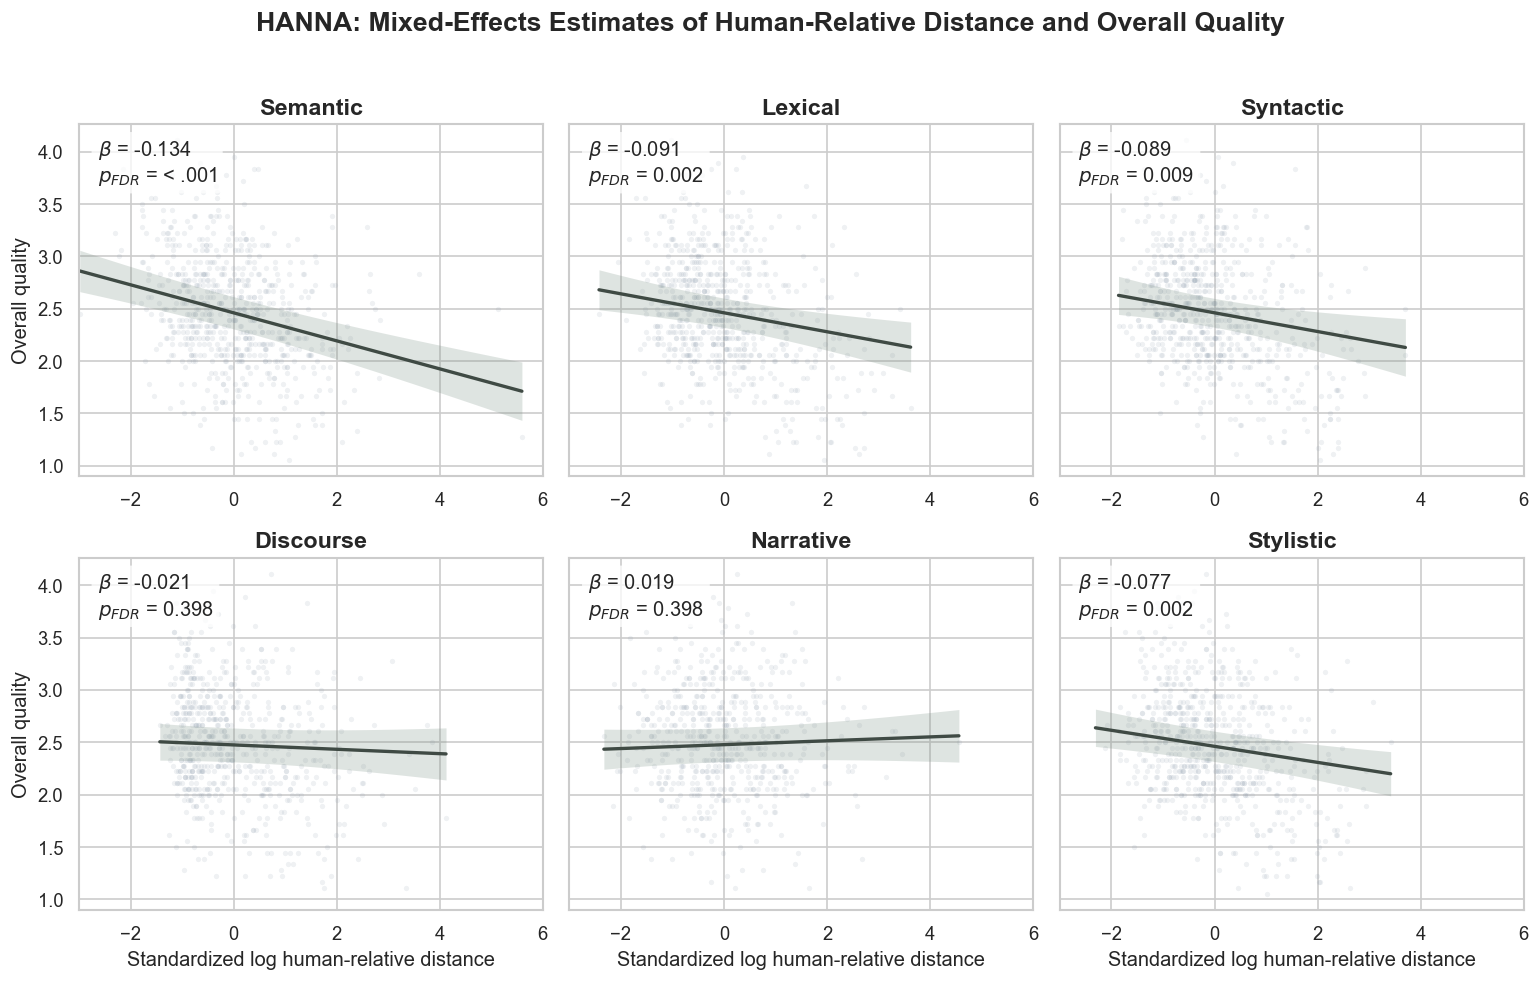

In [19]:
METRIC_LABELS = {
    'D_sem': 'Semantic', 'D_lex': 'Lexical', 'D_syn': 'Syntactic',
    'D_disc': 'Discourse', 'D_narr': 'Narrative', 'D_style': 'Stylistic',
}

y_all = df_quality_model['Overall']
y_pad = (y_all.max() - y_all.min()) * 0.05
YLIM = (y_all.min() - y_pad, y_all.max() + y_pad)

# Shared x-range across panels
all_x = np.concatenate([
    metric_subset(df_quality_model, metric)['log_r_mean_z'].dropna().to_numpy()
    for metric in PAIRING_METRICS
])

x_min = np.floor(np.min(all_x) * 2) / 2
x_max = np.ceil(np.max(all_x) * 2) / 2

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=True)

for ax, metric in zip(axes.flat, PAIRING_METRICS):
    sub = metric_subset(df_quality_model, metric).dropna(subset=['log_r_mean_z', 'Overall'])

    res = lmm_results[(metric, 'Overall')]
    row = df_lmm_results[(df_lmm_results.metric == metric) & (df_lmm_results.target == 'Overall')].iloc[0]

    x = sub['log_r_mean_z'].to_numpy()
    y = sub['Overall'].to_numpy()
    ax.scatter(x, y, s=10, alpha=0.12, color='#7f91a3', linewidths=0)

    # Fixed-effect regression line + 95% Wald band (delta method on the [Intercept, slope] covariance)
    x_grid = np.linspace(x.min(), x.max(), 200)
    b0, b1 = res.params['Intercept'], res.params['log_r_mean_z']
    cov_fe = res.cov_params().loc[['Intercept', 'log_r_mean_z'], ['Intercept', 'log_r_mean_z']].to_numpy()
    X = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X @ np.array([b0, b1])
    se_hat = np.sqrt(np.einsum('ij,jk,ik->i', X, cov_fe, X))

    ax.fill_between(x_grid, y_hat - 1.96 * se_hat, y_hat + 1.96 * se_hat,
                     color='#7f9488', alpha=0.25, linewidth=0)
    ax.plot(x_grid, y_hat, color='#3f4a44', linewidth=2)

    p_fdr = row['p_fdr']
    p_label = '< .001' if p_fdr < 0.001 else f'{p_fdr:.3f}'
    ax.text(0.04, 0.96, f"$\\beta$ = {row['coef']:.3f}\n$p_{{FDR}}$ = {p_label}",
            transform=ax.transAxes, ha='left', va='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, edgecolor='none'))

    ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight='bold')
    ax.set_ylim(*YLIM)
    ax.set_xlim(x_min, x_max)

for ax in axes[-1]:
    ax.set_xlabel('Standardized log human-relative distance', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel('Overall quality', fontsize=12)

fig.suptitle('HANNA: Mixed-Effects Estimates of Human-Relative Distance and Overall Quality',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('hanna_hrd_regression_panels.png')
plt.show()

### Secondary Analysis: Individual Quality Criteria

The same model with each of the six criteria as outcome. The 36 dimension × criterion tests form a separate FDR family.

In [20]:
SECONDARY_TARGETS = HUMAN_CRITERIA

lmm_results_secondary, df_lmm_secondary = fit_family(SECONDARY_TARGETS)
df_lmm_secondary.to_csv(RESULTS_DIR / 'hanna_hrd_mixedlm_results_secondary.csv', index=False)

print(f'Converged for all {len(df_lmm_secondary)} fits: {df_lmm_secondary["converged"].all()}\n')

coef_matrix_sec = df_lmm_secondary.pivot(index='metric', columns='target', values='coef').loc[PAIRING_METRICS, SECONDARY_TARGETS]
sig_matrix_sec = df_lmm_secondary.pivot(index='metric', columns='target', values='sig_fdr').loc[PAIRING_METRICS, SECONDARY_TARGETS]
print('Coefficients (FDR-corrected significance, secondary family only):')
display(coef_matrix_sec.round(3).astype(str) + sig_matrix_sec)

df_lmm_secondary.round(4)

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retva

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retva

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 14.040103
  warnings.warn(msg, ConvergenceWarning)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374:

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retva

Converged for all 36 fits: True

Coefficients (FDR-corrected significance, secondary family only):


target,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity
metric,,,,,,
D_sem,-0.392***,-0.094***,-0.085**,-0.056*,-0.124***,-0.109***
D_lex,-0.117*,-0.115**,-0.113**,-0.057,-0.103*,-0.095*
D_syn,-0.1*,-0.098*,-0.113*,-0.043,-0.105*,-0.172**
D_disc,0.025,0.035,-0.079*,-0.057,-0.039,-0.06
D_narr,0.054,0.049,-0.033,-0.012,0.019,-0.005
D_style,-0.099*,-0.114***,-0.048,-0.073*,-0.083*,-0.098**


,metric,target,coef,se,ci_low,ci_high,p,n,converged,prompt_var_pct,model_var_pct,residual_pct,sig,p_fdr,sig_fdr
0,D_sem,Relevance,-0.3921,0.0367,-0.4641,-0.3201,0.0000,680,True,20.5202,0.5851,78.8947,***,0.0000,***
1,D_sem,Coherence,-0.0944,0.0245,-0.1425,-0.0463,0.0001,680,True,1.7650,18.5913,79.6438,***,0.0009,***
2,D_sem,Empathy,-0.0854,0.0261,-0.1366,-0.0342,0.0011,680,True,6.5029,10.3609,83.1362,**,0.0039,**
3,D_sem,Surprise,-0.0563,0.0254,-0.1061,-0.0065,0.0268,680,True,5.9081,12.1178,81.9741,*,0.0439,*
4,D_sem,Engagement,-0.1237,0.0262,-0.1751,-0.0723,0.0000,680,True,1.8603,22.0706,76.0691,***,0.0000,***
5,D_sem,Complexity,-0.1094,0.0262,-0.1607,-0.0580,0.0000,680,True,6.4199,30.0641,63.5159,***,0.0004,***
6,D_lex,Relevance,-0.1168,0.0410,-0.1972,-0.0364,0.0044,680,True,10.8520,2.0646,87.0834,**,0.0123,*
7,D_lex,Coherence,-0.1151,0.0333,-0.1803,-0.0499,0.0005,680,True,2.9056,13.1747,83.9197,***,0.0028,**
8,D_lex,Empathy,-0.1133,0.0343,-0.1806,-0.0460,0.0010,680,True,8.3599,6.8509,84.7892,***,0.0039,**
9,D_lex,Surprise,-0.0565,0.0322,-0.1197,0.0066,0.0794,680,True,5.7549,10.3202,83.9248,,0.1100,


## Robustness Checks

Four checks on the primary model, each with its own Benjamini-Hochberg FDR correction:

1. **r_min instead of r_mean.** Distance to the nearest human reference instead of the mean distance.
2. **Length control.** A prompt-specific length-mismatch score \(\delta_L(t)\) is added as a second predictor.
3. **Deviation from r=1 / nonlinearity.** Fits `Overall ~ log(r_mean) + log(r_mean)^2` on the raw (unstandardized) scale instead, where `log(r_mean) = 0` is exactly `r = 1`.
4. **Variable reference count.** All prompts with at least two human references, using leave-one-out reference-control splits.

### r_min Instead of r_mean

In [21]:
rob_rows_rmin = []

for metric in PAIRING_METRICS:
    sub = metric_subset(df_quality_model, metric, score_col='r_min')
    res = fit_crossed_lmm(sub, 'Overall', predictor='log_r_min_z', label=f'{metric}/Overall (r_min)')

    rob_rows_rmin.append({
        'metric': metric,
        **term_summary(res, 'log_r_min_z', prefix='_r_min'),
        'n': int(res.nobs),
        'converged': res.converged,
        **variance_shares(res),
    })

df_rob_rmin = add_fdr(pd.DataFrame(rob_rows_rmin), 'p_r_min', suffix='_r_min')
df_rob_rmin.to_csv(RESULTS_DIR / 'hanna_hrd_robustness_rmin.csv', index=False)

print(f'Converged for all {len(df_rob_rmin)} fits: {df_rob_rmin["converged"].all()}\n')
display(df_rob_rmin[['metric', 'coef_r_min', 'ci_low_r_min', 'ci_high_r_min', 'p_fdr_r_min']].round(4))

# Side-by-side with the primary (r_mean) result
compare_rmin = df_lmm_results.loc[df_lmm_results.target == 'Overall',
                                  ['metric', 'coef', 'p_fdr', 'sig_fdr']].rename(
    columns={'coef': 'coef_r_mean', 'p_fdr': 'p_fdr_r_mean', 'sig_fdr': 'sig_fdr_r_mean'}
).merge(
    df_rob_rmin[['metric', 'coef_r_min', 'p_fdr_r_min', 'sig_fdr_r_min']], on='metric'
).set_index('metric').loc[PAIRING_METRICS]

print('r_mean (primary) vs. r_min (robustness), same sign and significance pattern expected:')
compare_rmin.round(4)

Converged for all 6 fits: True



/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

,metric,coef_r_min,ci_low_r_min,ci_high_r_min,p_fdr_r_min
0,D_sem,-0.1290,-0.1708,-0.0871,0.0000
1,D_lex,-0.0981,-0.1492,-0.0471,0.0005
2,D_syn,-0.0873,-0.1481,-0.0265,0.0074
3,D_disc,-0.0305,-0.0778,0.0168,0.2360
4,D_narr,0.0256,-0.0167,0.0678,0.2360
5,D_style,-0.0656,-0.1100,-0.0212,0.0074


r_mean (primary) vs. r_min (robustness), same sign and significance pattern expected:


,coef_r_mean,p_fdr_r_mean,sig_fdr_r_mean,coef_r_min,p_fdr_r_min,sig_fdr_r_min
metric,,,,,,
D_sem,-0.1338,0.0000,***,-0.1290,0.0000,***
D_lex,-0.0905,0.0018,**,-0.0981,0.0005,***
D_syn,-0.0893,0.0093,**,-0.0873,0.0074,**
D_disc,-0.0208,0.3982,,-0.0305,0.2360,
D_narr,0.0185,0.3982,,0.0256,0.2360,
D_style,-0.0766,0.0018,**,-0.0656,0.0074,**


### Length Control

`delta_L(t)` is the word-count difference to the human references, aggregated over the same reference-control splits as `r(t)`:

`Overall ~ log(r_mean)_z + delta_L(t)_z + (1 | Prompt) + (1 | Model)`

In [22]:
length_rows = []
for pid, segs in segments_by_prompt.items():

    # Pairwise absolute word-count differences between all texts (human + models) of this prompt
    texts = [t for _, seg in segs for t in seg]
    lengths = np.array([len(t.split()) for t in texts], dtype=float)
    L_dist = np.abs(lengths[:, None] - lengths[None, :])

    # Same reference-control aggregation as for the distance scores; only the mean-reference value is used
    length_rows += [(pid, src, local_idx, dl_mean)
                    for src, local_idx, dl_mean, _, _ in per_text_rows(L_dist, segs, REF_SIZE)]

df_delta_length = pd.DataFrame(length_rows, columns=['prompt_key', 'source', 'local_idx', 'delta_L_mean'])
LENGTH_MISMATCH_PATH = RESULTS_DIR / 'hanna_hrd_length_mismatch.csv'
df_delta_length.to_csv(LENGTH_MISMATCH_PATH, index=False)

if 'delta_L_mean' not in df_quality_model.columns:
    df_quality_model = df_quality_model.merge(
        df_delta_length, on=['prompt_key', 'source', 'local_idx'], how='left'
    )

print(f'{len(df_delta_length):,} per-text length-mismatch scores -> {LENGTH_MISMATCH_PATH}')
df_delta_length.groupby(df_delta_length.source.eq('human'))['delta_L_mean'].describe().round(2)

1,020 per-text length-mismatch scores -> results/hanna_hrd_length_mismatch.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
False,680.0,339.45,181.30,40.2,185.15,324.30,455.80,919.40
True,340.0,337.01,221.57,47.5,177.38,278.62,444.81,1352.25


In [23]:
rob_rows_length = []

for metric in PAIRING_METRICS:
    sub = metric_subset(df_quality_model, metric)
    sub['delta_L_mean_z'] = StandardScaler().fit_transform(sub[['delta_L_mean']])

    res = fit_crossed_lmm(
        sub, 'Overall', predictor='log_r_mean_z + delta_L_mean_z',
        dropna_cols=['Overall', 'log_r_mean_z', 'delta_L_mean_z'],
        label=f'{metric}/Overall (+length mismatch)',
    )

    rob_rows_length.append({
        'metric': metric,
        **term_summary(res, 'log_r_mean_z', prefix='_r_mean'),
        **term_summary(res, 'delta_L_mean_z', prefix='_length_mismatch', with_se=False),
        'n': int(res.nobs),
        'converged': res.converged,
    })

df_rob_length = add_fdr(pd.DataFrame(rob_rows_length), 'p_r_mean', suffix='_r_mean')
df_rob_length.to_csv(RESULTS_DIR / 'hanna_hrd_robustness_length.csv', index=False)

print(f'Converged for all {len(df_rob_length)} fits: {df_rob_length["converged"].all()}\n')
display(df_rob_length[['metric', 'coef_r_mean', 'ci_low_r_mean', 'ci_high_r_mean', 'p_fdr_r_mean']].round(4))

# Side-by-side with the primary (no length control) result
compare_length = df_lmm_results.loc[df_lmm_results.target == 'Overall',
                                    ['metric', 'coef', 'p_fdr', 'sig_fdr']].rename(
    columns={'coef': 'coef_no_control', 'p_fdr': 'p_fdr_no_control', 'sig_fdr': 'sig_fdr_no_control'}
).merge(
    df_rob_length[['metric', 'coef_r_mean', 'p_fdr_r_mean', 'sig_fdr_r_mean',
                   'coef_length_mismatch', 'p_length_mismatch']],
    on='metric'
).set_index('metric').loc[PAIRING_METRICS]

print('log(r_mean) effect with vs. without controlling for prompt-specific length mismatch:')
compare_length.round(4)

Converged for all 6 fits: True



/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

,metric,coef_r_mean,ci_low_r_mean,ci_high_r_mean,p_fdr_r_mean
0,D_sem,-0.1344,-0.1759,-0.0928,0.0000
1,D_lex,-0.1089,-0.1667,-0.0511,0.0007
2,D_syn,-0.1238,-0.1975,-0.0502,0.0015
3,D_disc,-0.0241,-0.0732,0.0249,0.3927
4,D_narr,0.0196,-0.0253,0.0644,0.3927
5,D_style,-0.0846,-0.1313,-0.0379,0.0008


log(r_mean) effect with vs. without controlling for prompt-specific length mismatch:


,coef_no_control,p_fdr_no_control,sig_fdr_no_control,coef_r_mean,p_fdr_r_mean,sig_fdr_r_mean,coef_length_mismatch,p_length_mismatch
metric,,,,,,,,
D_sem,-0.1338,0.0000,***,-0.1344,0.0000,***,0.0009,0.9688
D_lex,-0.0905,0.0018,**,-0.1089,0.0007,***,0.0384,0.1158
D_syn,-0.0893,0.0093,**,-0.1238,0.0015,**,0.0490,0.0682
D_disc,-0.0208,0.3982,,-0.0241,0.3927,,0.0083,0.7143
D_narr,0.0185,0.3982,,0.0196,0.3927,,-0.0043,0.8551
D_style,-0.0766,0.0018,**,-0.0846,0.0008,***,0.0251,0.2599


### Deviation from r=1 / Nonlinearity

In [24]:
QUAD_TERM = 'I(log_r_mean ** 2)'

rob_rows_quad = []

for metric in PAIRING_METRICS:
    sub = metric_subset(df_quality_model, metric, standardize=False)   # raw scale: log_r_mean == 0 <=> r == 1

    res = fit_crossed_lmm(
        sub, 'Overall', predictor=f'log_r_mean + {QUAD_TERM}',
        dropna_cols=['Overall', 'log_r_mean'],
        label=f'{metric}/Overall (quadratic)',
    )

    rob_rows_quad.append({
        'metric': metric,
        **term_summary(res, 'log_r_mean', prefix='_linear_at_r1', with_se=False),
        **term_summary(res, QUAD_TERM, prefix='_quadratic', with_se=False),
        'n': int(res.nobs),
        'converged': res.converged,
    })

# The FDR-corrected quadratic term is the nonlinearity test
df_rob_quad = add_fdr(pd.DataFrame(rob_rows_quad), 'p_quadratic', suffix='_quadratic')
df_rob_quad.to_csv(RESULTS_DIR / 'hanna_hrd_robustness_nonlinearity.csv', index=False)

print(f'Converged for all {len(df_rob_quad)} fits: {df_rob_quad["converged"].all()}\n')
print('Linear term = local slope at r=1; quadratic term = curvature (FDR-corrected p shown):')
df_rob_quad.set_index('metric').loc[PAIRING_METRICS].round(4)

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Converged for all 6 fits: True

Linear term = local slope at r=1; quadratic term = curvature (FDR-corrected p shown):


/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

,coef_linear_at_r1,ci_low_linear_at_r1,ci_high_linear_at_r1,p_linear_at_r1,coef_quadratic,ci_low_quadratic,ci_high_quadratic,p_quadratic,n,converged,p_fdr_quadratic,sig_fdr_quadratic
metric,,,,,,,,,,,,
D_sem,-0.9720,-1.3164,-0.6276,0.0000,0.5122,-0.0457,1.0701,0.0720,680,True,0.4317,
D_lex,-3.2716,-5.7861,-0.7570,0.0108,4.4689,-26.7851,35.7229,0.7793,680,True,0.7827,
D_syn,-0.6321,-1.1363,-0.1279,0.0140,0.3520,-0.3988,1.1028,0.3581,680,True,0.7163,
D_disc,-0.0734,-0.1665,0.0197,0.1225,0.0241,-0.0130,0.0612,0.2038,640,True,0.6114,
D_narr,0.0207,-0.2907,0.3320,0.8964,0.1371,-0.3800,0.6543,0.6032,584,True,0.7827,
D_style,-0.2517,-0.4867,-0.0168,0.0357,0.0336,-0.2050,0.2721,0.7827,679,True,0.7827,


### Variable Reference Count (n_refs >= 2)

All prompts with at least two human references, using every available reference. Each human text takes a turn as the control (leave-one-out, `REF_SIZE = n_human - 1`).

In [25]:
eligible_refs2 = df_refs.loc[df_refs['n_refs'] >= 2].copy()

eligible_keys2 = set(eligible_refs2['prompt_key'])
model_targets2 = stories.loc[
    (stories['Model'] != 'Human') &
    (stories['prompt_key'].isin(eligible_keys2))
].copy()

print(f"Eligible prompts (n_refs >= 2): {len(eligible_refs2)}")
print(eligible_refs2['n_refs'].value_counts().sort_index())
print(f"Model stories: {len(model_targets2)}, prompts with >=1 model story: "
      f"{model_targets2['prompt_key'].nunique()}")

Eligible prompts (n_refs >= 2): 93
n_refs
2      8
3     10
4      7
5      4
6      9
7      7
8      2
9      4
10     2
11     5
12     1
13     1
14     5
15     2
16     3
18     3
20     1
21     1
22     1
23     3
24     4
29     1
30     1
31     1
32     1
34     1
45     1
50     1
57     1
91     2
Name: count, dtype: int64
Model stories: 930, prompts with >=1 model story: 93


In [26]:
# Every available human reference, no subsampling
segments_by_prompt2, id_map2 = build_segments(eligible_refs2, 'human_refs', model_targets2)

print(f'{len(segments_by_prompt2)} prompts with human refs + model stories')
print('human refs per prompt:',
      pd.Series([len(v[0][1]) for v in segments_by_prompt2.values()]).describe())

93 prompts with human refs + model stories
human refs per prompt: count    93.000000
mean     13.645161
std      15.762949
min       2.000000
25%       4.000000
50%       8.000000
75%      16.000000
max      91.000000
dtype: float64


In [27]:
MATRIX_CACHE_V2 = RESULTS_DIR / 'hanna_pairing_matrices_v2ref.pkl'
pairing_matrices2 = load_or_compute_matrices(segments_by_prompt2, MATRIX_CACHE_V2)

D_sem: all 93 cached
D_lex: all 93 cached
D_syn: all 93 cached
D_disc: all 93 cached
D_narr: all 93 cached
D_style: all cached


In [28]:
rows_text2 = []

# Leave-one-out reference-control splits: every human text takes a turn as H_ctrl
for metric in PAIRING_METRICS:
    for pid, segs in segments_by_prompt2.items():
        M = pairing_matrices2.get((metric, pid))
        n_human = len(segs[0][1])
        if M is None or n_human < 2:   # can't leave one out with fewer than 2 human refs
            continue
        rows_text2 += [(metric, pid, *r) for r in per_text_rows(M, segs, n_human - 1)]

df_delta_text2 = pd.DataFrame(rows_text2, columns=DELTA_COLS)
df_score_text2 = add_r_scores(df_delta_text2)
SCORE_ALL_V2_PATH = RESULTS_DIR / 'hanna_hrd_score_all_v2ref.csv'
df_score_text2.to_csv(SCORE_ALL_V2_PATH, index=False)

print(f'{len(df_score_text2):,} per-text r(t) scores (variable-n, leave-one-out reference sets) -> '
      f'{SCORE_ALL_V2_PATH}')

12,898 per-text r(t) scores (variable-n, leave-one-out reference sets) -> results/hanna_hrd_score_all_v2ref.csv


In [29]:
df_quality2 = attach_quality(df_score_text2, id_map2)
df_quality_model2 = df_quality2[df_quality2['source'] != 'human'].copy()

print(f"Prompts with a valid r(t) (n_refs >= 2): {df_quality_model2['prompt_key'].nunique()}")
print(f"Unique model stories for the variable-n robustness check: {df_quality_model2['story_id'].nunique()}")
print(f"Model-story × dimension rows available: {len(df_quality_model2)}")

rob_rows_v2 = []

for metric in PAIRING_METRICS:
    sub = metric_subset(df_quality_model2, metric)
    res = fit_crossed_lmm(sub, 'Overall', predictor='log_r_mean_z',
                          label=f'{metric}/Overall (variable-n refs, LOO)')

    rob_rows_v2.append({
        'metric': metric,
        **term_summary(res, 'log_r_mean_z'),
        'n': int(res.nobs),
        'n_prompts': sub['prompt_key'].nunique(),
        'converged': res.converged,
    })

df_rob_v2 = add_fdr(pd.DataFrame(rob_rows_v2), 'p')
df_rob_v2.to_csv(RESULTS_DIR / 'hanna_hrd_robustness_variable_n.csv', index=False)

compare_v2 = df_lmm_results.loc[df_lmm_results.target == 'Overall',
                                ['metric', 'coef', 'ci_low', 'ci_high', 'p_fdr', 'sig_fdr']].rename(
    columns={'coef': 'coef_68p', 'ci_low': 'ci_low_68p', 'ci_high': 'ci_high_68p',
             'p_fdr': 'p_fdr_68p', 'sig_fdr': 'sig_fdr_68p'}
).merge(
    df_rob_v2[['metric', 'coef', 'ci_low', 'ci_high', 'p_fdr', 'sig_fdr', 'n_prompts']].rename(
        columns={'coef': 'coef_var_n', 'ci_low': 'ci_low_var_n', 'ci_high': 'ci_high_var_n',
                 'p_fdr': 'p_fdr_var_n', 'sig_fdr': 'sig_fdr_var_n'}
    ), on='metric'
).set_index('metric').loc[PAIRING_METRICS]

print('Primary (68 prompts, fixed n=5 / REF_SIZE=3) vs. variable-n (n_refs>=2, leave-one-out) robustness check:')
compare_v2.round(4)

Prompts with a valid r(t) (n_refs >= 2): 93
Unique model stories for the variable-n robustness check: 930
Model-story × dimension rows available: 5383


/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slo

Primary (68 prompts, fixed n=5 / REF_SIZE=3) vs. variable-n (n_refs>=2, leave-one-out) robustness check:


/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


,coef_68p,ci_low_68p,ci_high_68p,p_fdr_68p,sig_fdr_68p,coef_var_n,ci_low_var_n,ci_high_var_n,p_fdr_var_n,sig_fdr_var_n,n_prompts
metric,,,,,,,,,,,
D_sem,-0.1338,-0.1753,-0.0923,0.0000,***,-0.1452,-0.1802,-0.1103,0.0000,***,93
D_lex,-0.0905,-0.1440,-0.0371,0.0018,**,-0.1007,-0.1462,-0.0552,0.0000,***,93
D_syn,-0.0893,-0.1533,-0.0254,0.0093,**,-0.0978,-0.1559,-0.0396,0.0015,**,93
D_disc,-0.0208,-0.0671,0.0254,0.3982,,-0.0384,-0.0796,0.0028,0.0810,,93
D_narr,0.0185,-0.0245,0.0615,0.3982,,0.0110,-0.0263,0.0483,0.5622,,93
D_style,-0.0766,-0.1215,-0.0317,0.0018,**,-0.1027,-0.1404,-0.0650,0.0000,***,93
